In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [ ]:
file_path = '/content/drive/MyDrive/modified_bigBasket.csv'
df = pd.read_csv(file_path)

In [ ]:
orders = (
    df.groupby(["Member", "Order"])
      .agg(
          order_date=("Created On", "min"),
          basket_size=("SKU", "nunique")
      )
      .reset_index()
)

print(orders.head())
print()
print("Number of orders:", len(orders))
print("Average basket size:", orders["basket_size"].mean())
print("Median basket size:", orders["basket_size"].median())

   Member    Order                     order_date  basket_size
0  M04158  6755145  2014-06-30 08:44:00.096000043            1
1  M04158  6763407  2014-02-07 15:55:00.000000000            2
2  M04158  6785498  2014-06-19 16:30:59.616000069            3
3  M04158  6807524  2014-06-26 14:26:00.096000293            2
4  M04158  7348982  2013-10-17 01:20:00.384000060            3

Number of orders: 8387
Average basket size: 7.409204721592942
Median basket size: 7.0


In [ ]:
customer_metrics = (
    orders.groupby("Member")
    .agg(
        total_orders=("Order", "nunique"),
        first_order=("order_date", "min"),
        last_order=("order_date", "max"),
        avg_basket_size=("basket_size", "mean"),
        median_basket_size=("basket_size", "median")
    )
    .reset_index()
)

# Convert 'first_order' and 'last_order' columns to datetime objects
customer_metrics["first_order"] = pd.to_datetime(customer_metrics["first_order"])
customer_metrics["last_order"] = pd.to_datetime(customer_metrics["last_order"])

customer_metrics["customer_lifetime_days"] = (
    customer_metrics["last_order"]
    - customer_metrics["first_order"]
).dt.days

customer_metrics.head()

,Member,total_orders,first_order,last_order,avg_basket_size,median_basket_size,customer_lifetime_days
0,M04158,132,2012-04-12 20:09:00.000000000,2014-12-04 19:54:00.000000000,3.73,3.50,965
1,M08075,55,2012-12-14 14:14:00.383999930,2014-12-02 07:19:00.000000000,11.60,12.00,717
2,M09303,105,2013-01-09 07:57:00.000000000,2014-12-08 06:59:00.000000000,4.41,4.00,697
3,M09736,62,2013-07-12 11:13:00.000000000,2014-12-04 11:47:00.000000000,10.10,10.50,510
4,M12050,39,2012-12-29 20:42:59.615999688,2014-09-13 20:23:59.999999870,14.26,15.00,622


In [ ]:
sku_metrics = (
    df.groupby(["SKU", "Description"])
    .agg(
        purchase_count=("Order", "count"),
        unique_orders=("Order", "nunique"),
        unique_customers=("Member", "nunique")
    )
    .reset_index()
)

sku_metrics["customer_penetration"] = (
    sku_metrics["unique_customers"]
    / df["Member"].nunique()
    * 100
)

sku_metrics.head()

,SKU,Description,purchase_count,unique_orders,unique_customers,customer_penetration
0,6884195,Instant Noodles,29,29,13,12.26
1,7536640,Energy Drinks,2,2,2,1.89
2,7537167,Honey,6,6,5,4.72
3,7537178,Honey,4,4,4,3.77
4,7538018,Shaving Blade & Razors,8,8,4,3.77


In [ ]:
customer_sku = (
    df.groupby(["Member", "SKU", "Description"])
    .agg(
        purchase_count=("Order", "count"),
        first_purchase=("Created On", "min"),
        last_purchase=("Created On", "max")
    )
    .reset_index()
)

# Convert 'first_purchase' and 'last_purchase' columns to datetime objects
customer_sku["first_purchase"] = pd.to_datetime(customer_sku["first_purchase"])
customer_sku["last_purchase"] = pd.to_datetime(customer_sku["last_purchase"])

customer_sku["customer_sku_age_days"] = (
    customer_sku["last_purchase"]
    - customer_sku["first_purchase"]
).dt.days

customer_sku.head()

,Member,SKU,Description,purchase_count,first_purchase,last_purchase,customer_sku_age_days
0,M04158,7537167,Honey,1,2013-12-17 23:03:00.288000267,2013-12-17 23:03:00.288000267,0
1,M04158,7537178,Honey,1,2013-11-21 18:44:00.383999930,2013-11-21 18:44:00.383999930,0
2,M04158,7540256,Basmati Rice,2,2013-06-04 23:40:00.000000000,2014-02-06 12:01:00.000000000,246
3,M04158,7541573,"Glucose, Marie & Milk Biscuits",3,2013-02-25 22:18:59.903999706,2013-11-04 16:12:00.000000000,251
4,M04158,7542208,Basmati Rice,1,2012-12-26 15:22:00.191999965,2012-12-26 15:22:00.191999965,0


In [ ]:
customer_sku_history = (
    df[["Member", "SKU", "Description", "Created On", "Order"]]
    .sort_values(["Member", "SKU", "Created On"])
    .copy()
)

customer_sku_history["Created On"] = pd.to_datetime(customer_sku_history["Created On"])

customer_sku_history["previous_purchase"] = (
    customer_sku_history
    .groupby(["Member", "SKU"])["Created On"]
    .shift(1)
)

customer_sku_history["days_since_previous_purchase"] = (
    customer_sku_history["Created On"]
    - customer_sku_history["previous_purchase"]
).dt.total_seconds() / (24 * 60 * 60)

customer_sku_history.head(10)

,Member,SKU,Description,Created On,Order,previous_purchase,days_since_previous_purchase
0,M04158,7537167,Honey,2013-12-17 23:03:00.288000267,8311359,NaT,NaN
1,M04158,7537178,Honey,2013-11-21 18:44:00.383999930,8324556,NaT,NaN
2,M04158,7540256,Basmati Rice,2013-06-04 23:40:00.000000000,7648869,NaT,NaN
3,M04158,7540256,Basmati Rice,2014-02-06 12:01:00.000000000,7912748,2013-06-04 23:40:00.000000000,246.51
4,M04158,7541573,"Glucose, Marie & Milk Biscuits",2013-02-25 22:18:59.903999706,7671291,NaT,NaN
5,M04158,7541573,"Glucose, Marie & Milk Biscuits",2013-03-17 22:48:59.615999809,7693062,2013-02-25 22:18:59.903999706,20.02
6,M04158,7541573,"Glucose, Marie & Milk Biscuits",2013-11-04 16:12:00.000000000,7652460,2013-03-17 22:48:59.615999809,231.72
7,M04158,7542208,Basmati Rice,2012-12-26 15:22:00.191999965,7751334,NaT,NaN
8,M04158,7548730,Organic Flours,2013-05-08 15:08:00.000000000,7489842,NaT,NaN
9,M04158,7548730,Organic Flours,2013-09-29 17:21:59.904000077,7385672,2013-05-08 15:08:00.000000000,144.09


In [ ]:
reorder_features = (
    customer_sku_history
    .groupby(["Member", "SKU", "Description"])
    .agg(
        purchase_count=("Order", "nunique"),
        first_purchase=("Created On", "min"),
        last_purchase=("Created On", "max"),
        avg_reorder_interval=("days_since_previous_purchase", "mean"),
        median_reorder_interval=("days_since_previous_purchase", "median"),
        min_reorder_interval=("days_since_previous_purchase", "min"),
        max_reorder_interval=("days_since_previous_purchase", "max"),
        reorder_count=("days_since_previous_purchase", "count")
    )
    .reset_index()
)

reorder_features.head()

,Member,SKU,Description,purchase_count,first_purchase,last_purchase,avg_reorder_interval,median_reorder_interval,min_reorder_interval,max_reorder_interval,reorder_count
0,M04158,7537167,Honey,1,2013-12-17 23:03:00.288000267,2013-12-17 23:03:00.288000267,NaN,NaN,NaN,NaN,0
1,M04158,7537178,Honey,1,2013-11-21 18:44:00.383999930,2013-11-21 18:44:00.383999930,NaN,NaN,NaN,NaN,0
2,M04158,7540256,Basmati Rice,2,2013-06-04 23:40:00.000000000,2014-02-06 12:01:00.000000000,246.51,246.51,246.51,246.51,1
3,M04158,7541573,"Glucose, Marie & Milk Biscuits",3,2013-02-25 22:18:59.903999706,2013-11-04 16:12:00.000000000,125.87,125.87,20.02,231.72,2
4,M04158,7542208,Basmati Rice,1,2012-12-26 15:22:00.191999965,2012-12-26 15:22:00.191999965,NaN,NaN,NaN,NaN,0


In [ ]:
reorder_features["is_repeat"] = (
    reorder_features["purchase_count"] > 1
)

print(
    reorder_features["is_repeat"]
    .value_counts()
)

print()

print(
    "Repeat relationship percentage:",
    reorder_features["is_repeat"].mean() * 100
)

is_repeat
True     8328
False    7157
Name: count, dtype: int64

Repeat relationship percentage: 53.78107846302874


In [ ]:
dataset_end = df["Created On"].max()
dataset_end = pd.to_datetime(dataset_end)

reorder_features["recency_days"] = (
    dataset_end
    - reorder_features["last_purchase"]
).dt.total_seconds() / (24 * 60 * 60)

print("Dataset end:", dataset_end)

reorder_features[
    [
        "Member",
        "SKU",
        "Description",
        "purchase_count",
        "last_purchase",
        "recency_days"
    ]
].head(10)

Dataset end: 2014-12-09 21:35:00


,Member,SKU,Description,purchase_count,last_purchase,recency_days
0,M04158,7537167,Honey,1,2013-12-17 23:03:00.288000267,356.94
1,M04158,7537178,Honey,1,2013-11-21 18:44:00.383999930,383.12
2,M04158,7540256,Basmati Rice,2,2014-02-06 12:01:00.000000000,306.40
3,M04158,7541573,"Glucose, Marie & Milk Biscuits",3,2013-11-04 16:12:00.000000000,400.22
4,M04158,7542208,Basmati Rice,1,2012-12-26 15:22:00.191999965,713.26
5,M04158,7548730,Organic Flours,2,2013-09-29 17:21:59.904000077,436.18
6,M04158,7569802,Namkeen,1,2014-06-06 16:28:00.000000000,186.21
7,M04158,7572254,Cooking Sauce,2,2014-06-01 16:30:00.000000000,191.21
8,M04158,7572981,Honey,1,2014-05-25 23:30:59.903999956,197.92
9,M04158,7572986,Honey,1,2013-04-12 18:39:00.000000000,606.12


In [ ]:
customer_features = customer_metrics[
    [
        "Member",
        "total_orders",
        "avg_basket_size",
        "median_basket_size",
        "customer_lifetime_days"
    ]
].copy()

reorder_features = reorder_features.merge(
    customer_features,
    on="Member",
    how="left"
)

reorder_features.head()

,Member,SKU,Description,purchase_count,first_purchase,last_purchase,avg_reorder_interval,median_reorder_interval,min_reorder_interval,max_reorder_interval,reorder_count,is_repeat,recency_days,total_orders,avg_basket_size,median_basket_size,customer_lifetime_days
0,M04158,7537167,Honey,1,2013-12-17 23:03:00.288000267,2013-12-17 23:03:00.288000267,NaN,NaN,NaN,NaN,0,False,356.94,132,3.73,3.50,965
1,M04158,7537178,Honey,1,2013-11-21 18:44:00.383999930,2013-11-21 18:44:00.383999930,NaN,NaN,NaN,NaN,0,False,383.12,132,3.73,3.50,965
2,M04158,7540256,Basmati Rice,2,2013-06-04 23:40:00.000000000,2014-02-06 12:01:00.000000000,246.51,246.51,246.51,246.51,1,True,306.40,132,3.73,3.50,965
3,M04158,7541573,"Glucose, Marie & Milk Biscuits",3,2013-02-25 22:18:59.903999706,2013-11-04 16:12:00.000000000,125.87,125.87,20.02,231.72,2,True,400.22,132,3.73,3.50,965
4,M04158,7542208,Basmati Rice,1,2012-12-26 15:22:00.191999965,2012-12-26 15:22:00.191999965,NaN,NaN,NaN,NaN,0,False,713.26,132,3.73,3.50,965


In [ ]:
sku_features = sku_metrics[
    [
        "SKU",
        "purchase_count",
        "unique_orders",
        "unique_customers",
        "customer_penetration"
    ]
].copy()

sku_features = sku_features.rename(
    columns={
        "purchase_count": "sku_total_purchases",
        "unique_orders": "sku_total_orders",
        "unique_customers": "sku_unique_customers",
        "customer_penetration": "sku_customer_penetration"
    }
)

reorder_features = reorder_features.merge(
    sku_features,
    on="SKU",
    how="left"
)

reorder_features.head()

,Member,SKU,Description,purchase_count,first_purchase,last_purchase,avg_reorder_interval,median_reorder_interval,min_reorder_interval,max_reorder_interval,reorder_count,is_repeat,recency_days,total_orders,avg_basket_size,median_basket_size,customer_lifetime_days,sku_total_purchases,sku_total_orders,sku_unique_customers,sku_customer_penetration
0,M04158,7537167,Honey,1,2013-12-17 23:03:00.288000267,2013-12-17 23:03:00.288000267,NaN,NaN,NaN,NaN,0,False,356.94,132,3.73,3.50,965,6,6,5,4.72
1,M04158,7537178,Honey,1,2013-11-21 18:44:00.383999930,2013-11-21 18:44:00.383999930,NaN,NaN,NaN,NaN,0,False,383.12,132,3.73,3.50,965,4,4,4,3.77
2,M04158,7540256,Basmati Rice,2,2013-06-04 23:40:00.000000000,2014-02-06 12:01:00.000000000,246.51,246.51,246.51,246.51,1,True,306.40,132,3.73,3.50,965,5,5,4,3.77
3,M04158,7541573,"Glucose, Marie & Milk Biscuits",3,2013-02-25 22:18:59.903999706,2013-11-04 16:12:00.000000000,125.87,125.87,20.02,231.72,2,True,400.22,132,3.73,3.50,965,81,81,25,23.58
4,M04158,7542208,Basmati Rice,1,2012-12-26 15:22:00.191999965,2012-12-26 15:22:00.191999965,NaN,NaN,NaN,NaN,0,False,713.26,132,3.73,3.50,965,9,9,7,6.60


In [ ]:
print("Rows:", len(reorder_features))
print("Columns:", len(reorder_features.columns))

print()

print(reorder_features.columns.tolist())

Rows: 15485
Columns: 21

['Member', 'SKU', 'Description', 'purchase_count', 'first_purchase', 'last_purchase', 'avg_reorder_interval', 'median_reorder_interval', 'min_reorder_interval', 'max_reorder_interval', 'reorder_count', 'is_repeat', 'recency_days', 'total_orders', 'avg_basket_size', 'median_basket_size', 'customer_lifetime_days', 'sku_total_purchases', 'sku_total_orders', 'sku_unique_customers', 'sku_customer_penetration']


In [ ]:
reorder_features.describe().T

,count,mean,min,25%,50%,75%,max,std
SKU,"15,485.00","20,400,924.68","6,884,195.00","7,718,198.00","15,669,778.00","15,670,196.00","93,319,504.00","19,185,816.36"
purchase_count,"15,485.00",4.01,1.00,1.00,2.00,4.00,75.00,6.24
first_purchase,15485,2013-06-07 13:55:13.993632,2011-03-12 10:18:00,2012-12-13 10:18:00.288000256,2013-05-31 20:28:59.808000256,2014-01-06 17:36:00,2014-12-09 21:35:00,NaN
last_purchase,15485,2014-01-07 15:41:44.489716736,2011-03-12 14:53:00,2013-07-18 14:15:59.616000,2014-02-25 20:17:00.095999744,2014-08-19 11:19:59.808000256,2014-12-09 21:35:00,NaN
avg_reorder_interval,"8,328.00",129.74,0.00,49.54,88.07,163.07,"1,033.67",125.07
median_reorder_interval,"8,328.00",119.14,0.00,34.01,72.51,154.08,"1,033.67",128.90
min_reorder_interval,"8,328.00",83.62,0.00,7.49,27.93,97.71,"1,033.67",131.76
max_reorder_interval,"8,328.00",207.79,0.00,104.56,174.94,278.00,"1,033.67",145.65
reorder_count,"15,485.00",3.01,0.00,0.00,1.00,3.00,74.00,6.24
recency_days,"15,485.00",336.25,0.00,112.43,287.05,509.30,"1,368.28",254.44


In [ ]:
reorder_features.isna().sum().sort_values(
    ascending=False
).head(15)

,0
avg_reorder_interval,7157
max_reorder_interval,7157
min_reorder_interval,7157
median_reorder_interval,7157
Member,0
first_purchase,0
purchase_count,0
Description,0
SKU,0
last_purchase,0


In [ ]:
repeat_intervals = (
    customer_sku_history["days_since_previous_purchase"]
    .dropna()
)

print("Number of observed reorder intervals:", len(repeat_intervals))
print()

print("Reorder interval percentiles:")
print(
    repeat_intervals.quantile(
        [0.10, 0.25, 0.50, 0.75, 0.90]
    )
)

print()
print("Mean:", repeat_intervals.mean())
print("Median:", repeat_intervals.median())

Number of observed reorder intervals: 46656

Reorder interval percentiles:
0.10     6.70
0.25    14.01
0.50    33.83
0.75    86.59
0.90   182.51
Name: days_since_previous_purchase, dtype: float64

Mean: 71.05056870932405
Median: 33.826040555555764


In [ ]:
horizons = [30, 60, 90, 120, 180]

for days in horizons:
    percentage = (
        (repeat_intervals <= days).mean() * 100
    )

    print(
        f"Within {days:3d} days: "
        f"{percentage:.2f}% of observed reorders"
    )

Within  30 days: 46.43% of observed reorders
Within  60 days: 65.56% of observed reorders
Within  90 days: 75.91% of observed reorders
Within 120 days: 82.21% of observed reorders
Within 180 days: 89.79% of observed reorders


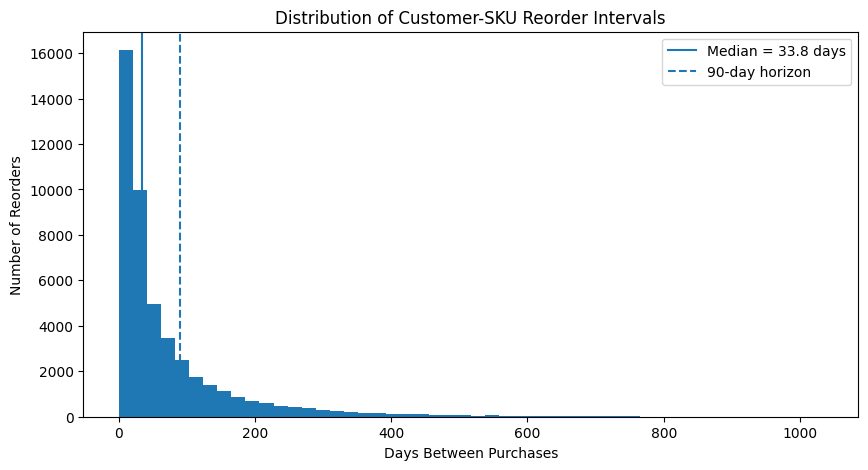

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    repeat_intervals,
    bins=50
)

plt.axvline(
    repeat_intervals.median(),
    linestyle="-",
    label=f"Median = {repeat_intervals.median():.1f} days"
)

plt.axvline(
    90,
    linestyle="--",
    label="90-day horizon"
)

plt.xlabel("Days Between Purchases")
plt.ylabel("Number of Reorders")
plt.title("Distribution of Customer-SKU Reorder Intervals")
plt.legend()
plt.show()

In [ ]:
df["Created On"] = pd.to_datetime(df["Created On"])

print("Dataset start:", df["Created On"].min())
print("Dataset end  :", df["Created On"].max())

print()
print("90 days after dataset start:",
      df["Created On"].min() + pd.Timedelta(days=90))

print("90 days before dataset end:",
      df["Created On"].max() - pd.Timedelta(days=90))

Dataset start: 2011-03-12 10:18:00
Dataset end  : 2014-12-09 21:35:00

90 days after dataset start: 2011-06-10 10:18:00
90 days before dataset end: 2014-09-10 21:35:00


In [ ]:
snapshot_dates = pd.to_datetime([
    "2013-06-30",
    "2013-09-30",
    "2013-12-31",
    "2014-03-31",
    "2014-06-30",

])

print("Snapshot dates:")
print(snapshot_dates)

Snapshot dates:
DatetimeIndex(['2013-06-30', '2013-09-30', '2013-12-31', '2014-03-31',
               '2014-06-30'],
              dtype='datetime64[ns]', freq=None)


In [ ]:
dataset_end = df["Created On"].max()

for date in snapshot_dates:
    future_end = date + pd.Timedelta(days=90)

    print(
        f"{date.date()}  ->  "
        f"future window ends {future_end.date()}  |  "
        f"usable: {future_end <= dataset_end}"
    )

2013-06-30  ->  future window ends 2013-09-28  |  usable: True
2013-09-30  ->  future window ends 2013-12-29  |  usable: True
2013-12-31  ->  future window ends 2014-03-31  |  usable: True
2014-03-31  ->  future window ends 2014-06-29  |  usable: True
2014-06-30  ->  future window ends 2014-09-28  |  usable: True


In [ ]:
snapshot_datasets = []

for snapshot in snapshot_dates:

    print(f"\nProcessing snapshot: {snapshot.date()}")

    # --------------------------------------------------
    # 1. Historical data: ONLY information available
    #    up to the snapshot date
    # --------------------------------------------------
    hist = df[df["Created On"] <= snapshot].copy()

    # Future window: ONLY used for creating the target
    future_end = snapshot + pd.Timedelta(days=90)

    future = df[
        (df["Created On"] > snapshot) &
        (df["Created On"] <= future_end)
    ].copy()

    # --------------------------------------------------
    # 2. Candidate Customer-SKU relationships
    # --------------------------------------------------
    candidates = (
        hist[
            ["Member", "SKU", "Description"]
        ]
        .drop_duplicates()
        .copy()
    )

    # --------------------------------------------------
    # 3. Customer-SKU historical features
    # --------------------------------------------------
    hist_sorted = hist.sort_values(
        ["Member", "SKU", "Created On"]
    ).copy()

    hist_sorted["interval_days"] = (
        hist_sorted
        .groupby(["Member", "SKU"])["Created On"]
        .diff()
        .dt.total_seconds()
        / 86400
    )

    customer_sku_features = (
        hist_sorted
        .groupby(["Member", "SKU"])
        .agg(
            purchase_count=("Order", "size"),
            first_purchase=("Created On", "min"),
            last_purchase=("Created On", "max"),
            avg_reorder_interval=("interval_days", "mean"),
            median_reorder_interval=("interval_days", "median"),
            min_reorder_interval=("interval_days", "min"),
            max_reorder_interval=("interval_days", "max")
        )
        .reset_index()
    )

    customer_sku_features["reorder_count"] = (
        customer_sku_features["purchase_count"] - 1
    )

    customer_sku_features["is_repeat"] = (
        customer_sku_features["purchase_count"] > 1
    )

    customer_sku_features["recency_days"] = (
        snapshot - customer_sku_features["last_purchase"]
    ).dt.total_seconds() / 86400

    # --------------------------------------------------
    # 4. Customer-level historical features
    # --------------------------------------------------

    # Unique SKUs per order
    customer_order_basket = (
        hist.groupby(["Member", "Order"])["SKU"]
        .nunique()
        .reset_index(name="basket_size")
    )

    customer_features = (
        customer_order_basket
        .groupby("Member")
        .agg(
            total_orders=("Order", "nunique"),
            avg_basket_size=("basket_size", "mean"),
            median_basket_size=("basket_size", "median")
        )
        .reset_index()
    )

    customer_dates = (
        hist.groupby("Member")["Created On"]
        .agg(
            customer_first_purchase="min",
            customer_last_purchase="max"
        )
        .reset_index()
    )

    customer_features = customer_features.merge(
        customer_dates,
        on="Member",
        how="left"
    )

    customer_features["customer_lifetime_days"] = (
        customer_features["customer_last_purchase"]
        - customer_features["customer_first_purchase"]
    ).dt.total_seconds() / 86400

    # --------------------------------------------------
    # 5. SKU-level historical features
    # --------------------------------------------------

    sku_features = (
        hist.groupby("SKU")
        .agg(
            sku_total_purchases=("Order", "size"),
            sku_total_orders=("Order", "nunique"),
            sku_unique_customers=("Member", "nunique")
        )
        .reset_index()
    )

    total_customers = hist["Member"].nunique()

    sku_features["sku_customer_penetration"] = (
        sku_features["sku_unique_customers"]
        / total_customers
        * 100
    )

    # --------------------------------------------------
    # 6. Merge all historical features
    # --------------------------------------------------

    snapshot_df = candidates.merge(
        customer_sku_features,
        on=["Member", "SKU"],
        how="left"
    )

    snapshot_df = snapshot_df.merge(
        customer_features,
        on="Member",
        how="left"
    )

    snapshot_df = snapshot_df.merge(
        sku_features,
        on="SKU",
        how="left"
    )

    # --------------------------------------------------
    # 7. Create the FUTURE 90-DAY TARGET
    # --------------------------------------------------

    future_reorders = (
        future[["Member", "SKU"]]
        .drop_duplicates()
        .assign(target_reorder=1)
    )

    snapshot_df = snapshot_df.merge(
        future_reorders,
        on=["Member", "SKU"],
        how="left"
    )

    snapshot_df["target_reorder"] = (
        snapshot_df["target_reorder"]
        .fillna(0)
        .astype(int)
    )

    # --------------------------------------------------
    # 8. Store snapshot date
    # --------------------------------------------------

    snapshot_df["snapshot_date"] = snapshot

    snapshot_datasets.append(snapshot_df)

    print("Historical rows:", len(hist))
    print("Candidate Customer-SKU pairs:", len(snapshot_df))
    print(
        "Positive targets:",
        snapshot_df["target_reorder"].sum()
    )
    print(
        "Positive rate:",
        f"{snapshot_df['target_reorder'].mean() * 100:.2f}%"
    )


# ------------------------------------------------------
# Combine all snapshots
# ------------------------------------------------------

model_df = pd.concat(
    snapshot_datasets,
    ignore_index=True
)

print("\n======================================")
print("FINAL MODELING DATASET")
print("======================================")

print("Rows:", len(model_df))
print("Columns:", len(model_df.columns))

print("\nTarget distribution:")
print(model_df["target_reorder"].value_counts())

print("\nTarget percentage:")
print(
    model_df["target_reorder"]
    .value_counts(normalize=True)
    * 100
)

print("\nShape:")
print(model_df.shape)


Processing snapshot: 2013-06-30
Historical rows: 22855
Candidate Customer-SKU pairs: 8341
Positive targets: 2679
Positive rate: 32.12%

Processing snapshot: 2013-09-30
Historical rows: 30726
Candidate Customer-SKU pairs: 10049
Positive targets: 2913
Positive rate: 28.99%

Processing snapshot: 2013-12-31
Historical rows: 37911
Candidate Customer-SKU pairs: 11455
Positive targets: 2884
Positive rate: 25.18%

Processing snapshot: 2014-03-31
Historical rows: 45294
Candidate Customer-SKU pairs: 12940
Positive targets: 3052
Positive rate: 23.59%

Processing snapshot: 2014-06-30
Historical rows: 52535
Candidate Customer-SKU pairs: 14096
Positive targets: 3116
Positive rate: 22.11%

FINAL MODELING DATASET
Rows: 56881
Columns: 25

Target distribution:
target_reorder
0    42237
1    14644
Name: count, dtype: int64

Target percentage:
target_reorder
0   74.26
1   25.74
Name: proportion, dtype: float64

Shape:
(56881, 25)


In [ ]:
# PHASE 2 — CELL 19

print(model_df.head())

print("\nShape:")
print(model_df.shape)

print("\nColumns:")
print(model_df.columns.tolist())

print("\nMissing values:")
print(model_df.isna().sum().sort_values(ascending=False))

print("\nTarget distribution:")
print(model_df["target_reorder"].value_counts())

print("\nTarget percentage:")
print(
    model_df["target_reorder"]
    .value_counts(normalize=True) * 100
)

   Member      SKU                     Description  purchase_count  \
0  M04158  7540256                    Basmati Rice               1   
1  M04158  7541573  Glucose, Marie & Milk Biscuits               2   
2  M04158  7542208                    Basmati Rice               1   
3  M04158  7548730                  Organic Flours               1   
4  M04158  7572254                   Cooking Sauce               1   

                 first_purchase                 last_purchase  \
0 2013-06-04 23:40:00.000000000 2013-06-04 23:40:00.000000000   
1 2013-02-25 22:18:59.903999706 2013-03-17 22:48:59.615999809   
2 2012-12-26 15:22:00.191999965 2012-12-26 15:22:00.191999965   
3 2013-05-08 15:08:00.000000000 2013-05-08 15:08:00.000000000   
4 2013-04-12 18:39:00.000000000 2013-04-12 18:39:00.000000000   

   avg_reorder_interval  median_reorder_interval  min_reorder_interval  \
0                   NaN                      NaN                   NaN   
1                 20.02                 

In [ ]:
snapshot_target = (
    model_df
    .groupby("snapshot_date")["target_reorder"]
    .agg(
        total_pairs="count",
        positive_reorders="sum",
        reorder_rate="mean"
    )
    .reset_index()
)

snapshot_target["reorder_rate"] *= 100

print(snapshot_target)

  snapshot_date  total_pairs  positive_reorders  reorder_rate
0    2013-06-30         8341               2679         32.12
1    2013-09-30        10049               2913         28.99
2    2013-12-31        11455               2884         25.18
3    2014-03-31        12940               3052         23.59
4    2014-06-30        14096               3116         22.11


In [ ]:
train_dates = pd.to_datetime([
    "2013-06-30",
    "2013-09-30",
    "2013-12-31"
])

validation_date = pd.Timestamp("2014-03-31")
test_date = pd.Timestamp("2014-06-30")

train_df = model_df[
    model_df["snapshot_date"].isin(train_dates)
].copy()

validation_df = model_df[
    model_df["snapshot_date"] == validation_date
].copy()

test_df = model_df[
    model_df["snapshot_date"] == test_date
].copy()

print("TRAIN")
print("Rows:", len(train_df))
print("Positive rate:", train_df["target_reorder"].mean() * 100)

print("\nVALIDATION")
print("Rows:", len(validation_df))
print("Positive rate:", validation_df["target_reorder"].mean() * 100)

print("\nTEST")
print("Rows:", len(test_df))
print("Positive rate:", test_df["target_reorder"].mean() * 100)

TRAIN
Rows: 29845
Positive rate: 28.40006701289998

VALIDATION
Rows: 12940
Positive rate: 23.58578052550232

TEST
Rows: 14096
Positive rate: 22.105561861520997


In [ ]:
feature_columns = [
    "purchase_count",
    "reorder_count",
    "is_repeat",
    "recency_days",

    "total_orders",
    "avg_basket_size",
    "median_basket_size",
    "customer_lifetime_days",

    "sku_total_purchases",
    "sku_total_orders",
    "sku_unique_customers",
    "sku_customer_penetration",

    "avg_reorder_interval",
    "median_reorder_interval",
    "min_reorder_interval",
    "max_reorder_interval"
]

target_column = "target_reorder"

X_train = train_df[feature_columns].copy()
y_train = train_df[target_column].copy()

X_val = validation_df[feature_columns].copy()
y_val = validation_df[target_column].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df[target_column].copy()

print("Number of features:", len(feature_columns))
print("\nFeatures:")
print(feature_columns)

print("\nTraining shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Number of features: 16

Features:
['purchase_count', 'reorder_count', 'is_repeat', 'recency_days', 'total_orders', 'avg_basket_size', 'median_basket_size', 'customer_lifetime_days', 'sku_total_purchases', 'sku_total_orders', 'sku_unique_customers', 'sku_customer_penetration', 'avg_reorder_interval', 'median_reorder_interval', 'min_reorder_interval', 'max_reorder_interval']

Training shape: (29845, 16)
Validation shape: (12940, 16)
Test shape: (14096, 16)


In [ ]:
# PHASE 2 — CELL 23
# Median imputation using TRAINING data only

interval_columns = [
    "avg_reorder_interval",
    "median_reorder_interval",
    "min_reorder_interval",
    "max_reorder_interval"
]

for col in interval_columns:

    train_median = X_train[col].median()

    X_train[col] = X_train[col].fillna(train_median)
    X_val[col] = X_val[col].fillna(train_median)
    X_test[col] = X_test[col].fillna(train_median)

    print(
        f"{col}: training median used = {train_median:.2f}"
    )

print("\nRemaining missing values:")
print("Train:", X_train.isna().sum().sum())
print("Validation:", X_val.isna().sum().sum())
print("Test:", X_test.isna().sum().sum())

avg_reorder_interval: training median used = 65.94
median_reorder_interval: training median used = 56.08
min_reorder_interval: training median used = 25.68
max_reorder_interval: training median used = 120.11

Remaining missing values:
Train: 0
Validation: 0
Test: 0


In [ ]:
# PHASE 2 — CELL 24
# Baseline Logistic Regression

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train
logistic_model.fit(X_train, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [ ]:
# PHASE 2 — CELL 25
# Generate validation and test predictions

y_val_proba = logistic_model.predict_proba(X_val)[:, 1]
y_test_proba = logistic_model.predict_proba(X_test)[:, 1]

print("Validation predictions:", len(y_val_proba))
print("Test predictions:", len(y_test_proba))

print("\nFirst 10 validation probabilities:")
print(y_val_proba[:10])

Validation predictions: 12940
Test predictions: 14096

First 10 validation probabilities:
[0.09372933 0.08437649 0.17301326 0.25052045 0.02504798 0.1368668
 0.04583413 0.03640765 0.02230208 0.26544401]


In [ ]:
# PHASE 2 — CELL 26
# Evaluate Logistic Regression

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Convert probabilities to class predictions using 0.5 threshold
y_val_pred = (y_val_proba >= 0.5).astype(int)
y_test_pred = (y_test_proba >= 0.5).astype(int)

print("===== VALIDATION RESULTS =====")

print("ROC-AUC:",
      roc_auc_score(y_val, y_val_proba))

print("PR-AUC:",
      average_precision_score(y_val, y_val_proba))

print("Accuracy:",
      accuracy_score(y_val, y_val_pred))

print("Precision:",
      precision_score(y_val, y_val_pred, zero_division=0))

print("Recall:",
      recall_score(y_val, y_val_pred, zero_division=0))

print("F1:",
      f1_score(y_val, y_val_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))


print("\n===== TEST RESULTS =====")

print("ROC-AUC:",
      roc_auc_score(y_test, y_test_proba))

print("PR-AUC:",
      average_precision_score(y_test, y_test_proba))

print("Accuracy:",
      accuracy_score(y_test, y_test_pred))

print("Precision:",
      precision_score(y_test, y_test_pred, zero_division=0))

print("Recall:",
      recall_score(y_test, y_test_pred, zero_division=0))

print("F1:",
      f1_score(y_test, y_test_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

===== VALIDATION RESULTS =====
ROC-AUC: 0.8107837431924315
PR-AUC: 0.6102927458477558
Accuracy: 0.8157650695517774
Precision: 0.6695431472081218
Recall: 0.432175622542595
F1: 0.5252887295898049

Confusion Matrix:
[[9237  651]
 [1733 1319]]

===== TEST RESULTS =====
ROC-AUC: 0.8153117408007559
PR-AUC: 0.5978938546487642
Accuracy: 0.8200198637911464
Precision: 0.6505460218408736
Recall: 0.4014762516046213
F1: 0.496527088708077

Confusion Matrix:
[[10308   672]
 [ 1865  1251]]


In [ ]:
# PHASE 2 — CELL 27
# Random Forest baseline

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [ ]:
# PHASE 2 — CELL 28
# Random Forest predictions

y_val_rf_proba = rf_model.predict_proba(X_val)[:, 1]
y_test_rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("Validation predictions:", len(y_val_rf_proba))
print("Test predictions:", len(y_test_rf_proba))

print("\nFirst 10 validation probabilities:")
print(y_val_rf_proba[:10])

Validation predictions: 12940
Test predictions: 14096

First 10 validation probabilities:
[0.13490443 0.12240609 0.33456046 0.39103829 0.05299521 0.29079618
 0.15313412 0.05673162 0.10688768 0.41307812]


In [ ]:
# PHASE 2 — CELL 29
# Evaluate Random Forest

y_val_rf_pred = (y_val_rf_proba >= 0.5).astype(int)
y_test_rf_pred = (y_test_rf_proba >= 0.5).astype(int)

print("===== RANDOM FOREST — VALIDATION =====")

print("ROC-AUC:",
      roc_auc_score(y_val, y_val_rf_proba))

print("PR-AUC:",
      average_precision_score(y_val, y_val_rf_proba))

print("Accuracy:",
      accuracy_score(y_val, y_val_rf_pred))

print("Precision:",
      precision_score(y_val, y_val_rf_pred, zero_division=0))

print("Recall:",
      recall_score(y_val, y_val_rf_pred, zero_division=0))

print("F1:",
      f1_score(y_val, y_val_rf_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_rf_pred))


print("\n===== RANDOM FOREST — TEST =====")

print("ROC-AUC:",
      roc_auc_score(y_test, y_test_rf_proba))

print("PR-AUC:",
      average_precision_score(y_test, y_test_rf_proba))

print("Accuracy:",
      accuracy_score(y_test, y_test_rf_pred))

print("Precision:",
      precision_score(y_test, y_test_rf_pred, zero_division=0))

print("Recall:",
      recall_score(y_test, y_test_rf_pred, zero_division=0))

print("F1:",
      f1_score(y_test, y_test_rf_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_rf_pred))

===== RANDOM FOREST — VALIDATION =====
ROC-AUC: 0.821252931257343
PR-AUC: 0.6445394190535059
Accuracy: 0.7970633693972179
Precision: 0.5610665137614679
Recall: 0.641218872870249
F1: 0.5984709480122324

Confusion Matrix:
[[8357 1531]
 [1095 1957]]

===== RANDOM FOREST — TEST =====
ROC-AUC: 0.8229974676795949
PR-AUC: 0.6246706707414978
Accuracy: 0.8087400681044268
Precision: 0.5616559013505579
Recall: 0.6139281129653402
F1: 0.5866298681386077

Confusion Matrix:
[[9487 1493]
 [1203 1913]]


In [ ]:
# PHASE 2 — CELL 30
# Baseline model comparison

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Validation ROC-AUC": [
        roc_auc_score(y_val, y_val_proba),
        roc_auc_score(y_val, y_val_rf_proba)
    ],

    "Validation PR-AUC": [
        average_precision_score(y_val, y_val_proba),
        average_precision_score(y_val, y_val_rf_proba)
    ],

    "Test ROC-AUC": [
        roc_auc_score(y_test, y_test_proba),
        roc_auc_score(y_test, y_test_rf_proba)
    ],

    "Test PR-AUC": [
        average_precision_score(y_test, y_test_proba),
        average_precision_score(y_test, y_test_rf_proba)
    ]
})

print(comparison.round(4))

                 Model  Validation ROC-AUC  Validation PR-AUC  Test ROC-AUC  \
0  Logistic Regression                0.81               0.61          0.82   
1        Random Forest                0.82               0.64          0.82   

   Test PR-AUC  
0         0.60  
1         0.62  


In [ ]:
# PHASE 2 — CELL 31
# Decision Tree baseline

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree training completed.")

Decision Tree training completed.


In [ ]:
# PHASE 2 — CELL 32
# Decision Tree predictions

y_val_dt_proba = dt_model.predict_proba(X_val)[:, 1]
y_test_dt_proba = dt_model.predict_proba(X_test)[:, 1]

print("Validation predictions:", len(y_val_dt_proba))
print("Test predictions:", len(y_test_dt_proba))

Validation predictions: 12940
Test predictions: 14096


In [ ]:
# PHASE 2 — CELL 33
# Decision Tree evaluation

y_val_dt_pred = (y_val_dt_proba >= 0.5).astype(int)
y_test_dt_pred = (y_test_dt_proba >= 0.5).astype(int)

print("===== DECISION TREE — VALIDATION =====")

print("ROC-AUC:",
      roc_auc_score(y_val, y_val_dt_proba))

print("PR-AUC:",
      average_precision_score(y_val, y_val_dt_proba))

print("Accuracy:",
      accuracy_score(y_val, y_val_dt_pred))

print("Precision:",
      precision_score(y_val, y_val_dt_pred, zero_division=0))

print("Recall:",
      recall_score(y_val, y_val_dt_pred, zero_division=0))

print("F1:",
      f1_score(y_val, y_val_dt_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_dt_pred))


print("\n===== DECISION TREE — TEST =====")

print("ROC-AUC:",
      roc_auc_score(y_test, y_test_dt_proba))

print("PR-AUC:",
      average_precision_score(y_test, y_test_dt_proba))

print("Accuracy:",
      accuracy_score(y_test, y_test_dt_pred))

print("Precision:",
      precision_score(y_test, y_test_dt_pred, zero_division=0))

print("Recall:",
      recall_score(y_test, y_test_dt_pred, zero_division=0))

print("F1:",
      f1_score(y_test, y_test_dt_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_dt_pred))

===== DECISION TREE — VALIDATION =====
ROC-AUC: 0.7915373513627861
PR-AUC: 0.5949775637183791
Accuracy: 0.7557959814528593
Precision: 0.487075155576831
Recall: 0.666775884665793
F1: 0.5629322268326418

Confusion Matrix:
[[7745 2143]
 [1017 2035]]

===== DECISION TREE — TEST =====
ROC-AUC: 0.800130167231353
PR-AUC: 0.5889869594546524
Accuracy: 0.7705732122587968
Precision: 0.48579682233991334
Recall: 0.6476251604621309
F1: 0.5551581843191197

Confusion Matrix:
[[8844 2136]
 [1098 2018]]


In [ ]:
# PHASE 2 — CELL 34
# KNN preprocessing

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

knn_scaler = StandardScaler()

X_train_knn = knn_scaler.fit_transform(X_train)
X_val_knn = knn_scaler.transform(X_val)
X_test_knn = knn_scaler.transform(X_test)

print("KNN feature scaling completed.")

KNN feature scaling completed.


In [ ]:
# PHASE 2 — CELL 35
# KNN baseline

knn_model = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    n_jobs=-1
)

knn_model.fit(X_train_knn, y_train)

print("KNN training completed.")

KNN training completed.


In [ ]:
# PHASE 2 — CELL 36
# KNN predictions

y_val_knn_proba = knn_model.predict_proba(X_val_knn)[:, 1]
y_test_knn_proba = knn_model.predict_proba(X_test_knn)[:, 1]

print("Validation predictions:", len(y_val_knn_proba))
print("Test predictions:", len(y_test_knn_proba))

Validation predictions: 12940
Test predictions: 14096


In [ ]:
# PHASE 2 — CELL 37
# KNN evaluation

y_val_knn_pred = (y_val_knn_proba >= 0.5).astype(int)
y_test_knn_pred = (y_test_knn_proba >= 0.5).astype(int)

print("===== KNN — VALIDATION =====")

print("ROC-AUC:",
      roc_auc_score(y_val, y_val_knn_proba))

print("PR-AUC:",
      average_precision_score(y_val, y_val_knn_proba))

print("Accuracy:",
      accuracy_score(y_val, y_val_knn_pred))

print("Precision:",
      precision_score(y_val, y_val_knn_pred, zero_division=0))

print("Recall:",
      recall_score(y_val, y_val_knn_pred, zero_division=0))

print("F1:",
      f1_score(y_val, y_val_knn_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_knn_pred))


print("\n===== KNN — TEST =====")

print("ROC-AUC:",
      roc_auc_score(y_test, y_test_knn_proba))

print("PR-AUC:",
      average_precision_score(y_test, y_test_knn_proba))

print("Accuracy:",
      accuracy_score(y_test, y_test_knn_pred))

print("Precision:",
      precision_score(y_test, y_test_knn_pred, zero_division=0))

print("Recall:",
      recall_score(y_test, y_test_knn_pred, zero_division=0))

print("F1:",
      f1_score(y_test, y_test_knn_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_knn_pred))

===== KNN — VALIDATION =====
ROC-AUC: 0.7959285047578754
PR-AUC: 0.5873715016198111
Accuracy: 0.808887171561051
Precision: 0.6357243319268636
Recall: 0.4442988204456094
F1: 0.5230472516875603

Confusion Matrix:
[[9111  777]
 [1696 1356]]

===== KNN — TEST =====
ROC-AUC: 0.7937484509120329
PR-AUC: 0.5560889445425595
Accuracy: 0.8181753688989785
Precision: 0.6257389722601182
Recall: 0.441591784338896
F1: 0.5177798682972719

Confusion Matrix:
[[10157   823]
 [ 1740  1376]]


In [ ]:
# PHASE 2 — CELL 41
# HistGradientBoosting baseline

from sklearn.ensemble import HistGradientBoostingClassifier

hgb_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=1.0,
    class_weight="balanced",
    random_state=42
)

hgb_model.fit(X_train, y_train)

print("HistGradientBoosting training completed.")

HistGradientBoosting training completed.


In [ ]:
# PHASE 2 — CELL 42
# HistGradientBoosting predictions

y_val_hgb_proba = hgb_model.predict_proba(X_val)[:, 1]
y_test_hgb_proba = hgb_model.predict_proba(X_test)[:, 1]

print("Validation predictions:", len(y_val_hgb_proba))
print("Test predictions:", len(y_test_hgb_proba))

print("\nFirst 10 validation probabilities:")
print(y_val_hgb_proba[:10])

Validation predictions: 12940
Test predictions: 14096

First 10 validation probabilities:
[0.1037853  0.08131518 0.23604857 0.30215799 0.04415538 0.17744977
 0.12231882 0.04917266 0.08232637 0.51216019]


In [ ]:
# PHASE 2 — CELL 43
# HistGradientBoosting evaluation

y_val_hgb_pred = (y_val_hgb_proba >= 0.5).astype(int)
y_test_hgb_pred = (y_test_hgb_proba >= 0.5).astype(int)

print("===== HISTGRADIENTBOOSTING — VALIDATION =====")

print("ROC-AUC:",
      roc_auc_score(y_val, y_val_hgb_proba))

print("PR-AUC:",
      average_precision_score(y_val, y_val_hgb_proba))

print("Accuracy:",
      accuracy_score(y_val, y_val_hgb_pred))

print("Precision:",
      precision_score(y_val, y_val_hgb_pred, zero_division=0))

print("Recall:",
      recall_score(y_val, y_val_hgb_pred, zero_division=0))

print("F1:",
      f1_score(y_val, y_val_hgb_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_hgb_pred))


print("\n===== HISTGRADIENTBOOSTING — TEST =====")

print("ROC-AUC:",
      roc_auc_score(y_test, y_test_hgb_proba))

print("PR-AUC:",
      average_precision_score(y_test, y_test_hgb_proba))

print("Accuracy:",
      accuracy_score(y_test, y_test_hgb_pred))

print("Precision:",
      precision_score(y_test, y_test_hgb_pred, zero_division=0))

print("Recall:",
      recall_score(y_test, y_test_hgb_pred, zero_division=0))

print("F1:",
      f1_score(y_test, y_test_hgb_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_hgb_pred))

===== HISTGRADIENTBOOSTING — VALIDATION =====
ROC-AUC: 0.8165413641964312
PR-AUC: 0.6367365234476988
Accuracy: 0.7774343122102009
Precision: 0.5220286885245902
Recall: 0.6677588466579292
F1: 0.5859689476710753

Confusion Matrix:
[[8022 1866]
 [1014 2038]]

===== HISTGRADIENTBOOSTING — TEST =====
ROC-AUC: 0.8111834505963696
PR-AUC: 0.6124372240895841
Accuracy: 0.7879540295119183
Precision: 0.5162113862649987
Recall: 0.6489088575096277
F1: 0.5750035546708375

Confusion Matrix:
[[9085 1895]
 [1094 2022]]


In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = {
    "Logistic Regression": (y_val_proba, y_test_proba),
    "Random Forest": (y_val_rf_proba, y_test_rf_proba),
    "Decision Tree": (y_val_dt_proba, y_test_dt_proba),
    "KNN": (y_val_knn_proba, y_test_knn_proba),
    "HistGradientBoosting": (y_val_hgb_proba, y_test_hgb_proba)
}

results = []

for name, (val_proba, test_proba) in models.items():

    val_pred = (val_proba >= 0.5).astype(int)
    test_pred = (test_proba >= 0.5).astype(int)

    results.append({
        "Model": name,

        "Validation ROC-AUC":
            roc_auc_score(y_val, val_proba),

        "Validation PR-AUC":
            average_precision_score(y_val, val_proba),

        "Validation Accuracy":
            accuracy_score(y_val, val_pred),

        "Validation Precision":
            precision_score(y_val, val_pred, zero_division=0),

        "Validation Recall":
            recall_score(y_val, val_pred, zero_division=0),

        "Validation F1":
            f1_score(y_val, val_pred, zero_division=0),

        "Test ROC-AUC":
            roc_auc_score(y_test, test_proba),

        "Test PR-AUC":
            average_precision_score(y_test, test_proba),

        "Test Accuracy":
            accuracy_score(y_test, test_pred),

        "Test Precision":
            precision_score(y_test, test_pred, zero_division=0),

        "Test Recall":
            recall_score(y_test, test_pred, zero_division=0),

        "Test F1":
            f1_score(y_test, test_pred, zero_division=0)
    })

model_comparison = pd.DataFrame(results)

print(model_comparison.round(4).to_string(index=False))

               Model  Validation ROC-AUC  Validation PR-AUC  Validation Accuracy  Validation Precision  Validation Recall  Validation F1  Test ROC-AUC  Test PR-AUC  Test Accuracy  Test Precision  Test Recall  Test F1
 Logistic Regression                0.81               0.61                 0.82                  0.67               0.43           0.53          0.82         0.60           0.82            0.65         0.40     0.50
       Random Forest                0.82               0.64                 0.80                  0.56               0.64           0.60          0.82         0.62           0.81            0.56         0.61     0.59
       Decision Tree                0.79               0.59                 0.76                  0.49               0.67           0.56          0.80         0.59           0.77            0.49         0.65     0.56
                 KNN                0.80               0.59                 0.81                  0.64               0.44           

In [ ]:
# PHASE 2 — CELL 45
# Sort models by Test PR-AUC

comparison_sorted = (
    model_comparison
    .sort_values("Test PR-AUC", ascending=False)
    .reset_index(drop=True)
)

print(comparison_sorted.round(4).to_string(index=False))

               Model  Validation ROC-AUC  Validation PR-AUC  Validation Accuracy  Validation Precision  Validation Recall  Validation F1  Test ROC-AUC  Test PR-AUC  Test Accuracy  Test Precision  Test Recall  Test F1
       Random Forest                0.82               0.64                 0.80                  0.56               0.64           0.60          0.82         0.62           0.81            0.56         0.61     0.59
HistGradientBoosting                0.82               0.64                 0.78                  0.52               0.67           0.59          0.81         0.61           0.79            0.52         0.65     0.57
 Logistic Regression                0.81               0.61                 0.82                  0.67               0.43           0.53          0.82         0.60           0.82            0.65         0.40     0.50
       Decision Tree                0.79               0.59                 0.76                  0.49               0.67           

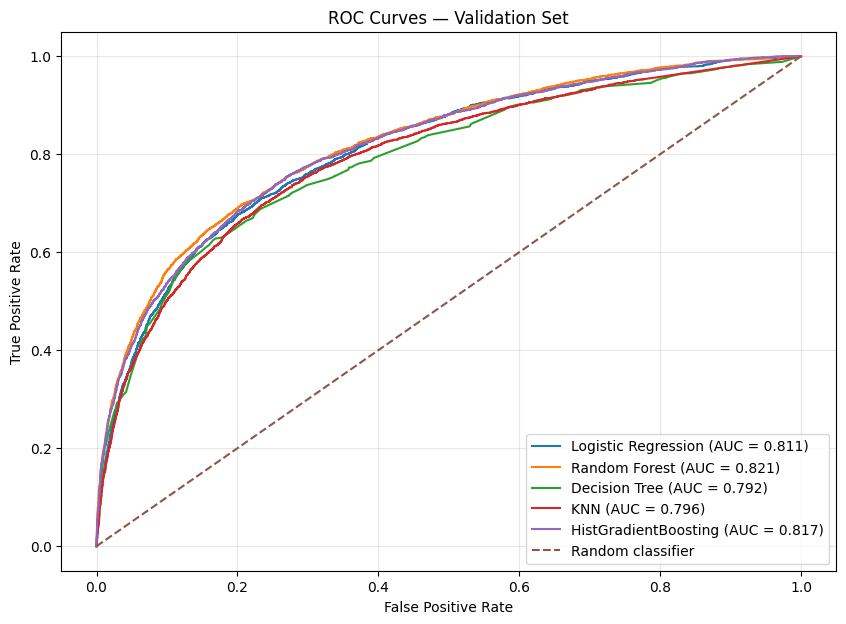

In [ ]:
# PHASE 2 — CELL 46
# ROC-AUC comparison

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 7))

for name, (val_proba, _) in models.items():

    fpr, tpr, _ = roc_curve(y_val, val_proba)
    auc = roc_auc_score(y_val, val_proba)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Validation Set")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

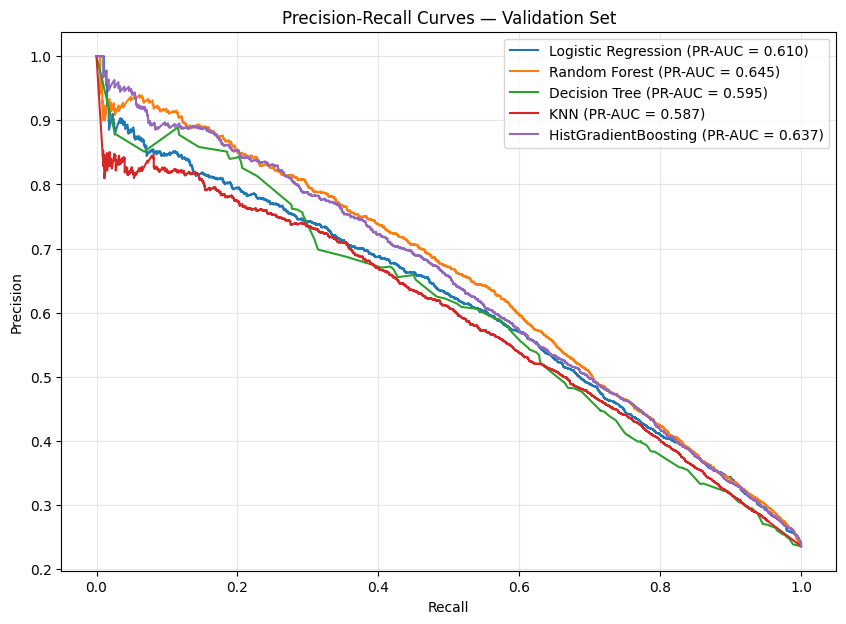

In [ ]:
# PHASE 2 — CELL 47
# Precision-Recall comparison

from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(10, 7))

for name, (val_proba, _) in models.items():

    precision, recall, _ = precision_recall_curve(
        y_val,
        val_proba
    )

    pr_auc = average_precision_score(
        y_val,
        val_proba
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} (PR-AUC = {pr_auc:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — Validation Set")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# PHASE 2 — CELL 48
# Random Forest threshold analysis

import numpy as np

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred = (
        y_val_rf_proba >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_val,
            y_pred,
            zero_division=0
        ),
        "Accuracy": accuracy_score(
            y_val,
            y_pred
        )
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df.round(4).to_string(index=False))

 Threshold  Precision  Recall   F1  Accuracy
      0.10       0.26    0.99 0.41      0.33
      0.15       0.28    0.97 0.44      0.41
      0.20       0.32    0.93 0.47      0.51
      0.25       0.35    0.88 0.51      0.59
      0.30       0.39    0.84 0.53      0.66
      0.35       0.43    0.79 0.56      0.70
      0.40       0.46    0.75 0.57      0.74
      0.45       0.51    0.70 0.59      0.77
      0.50       0.56    0.64 0.60      0.80
      0.55       0.62    0.58 0.60      0.82
      0.60       0.66    0.51 0.58      0.82
      0.65       0.70    0.46 0.55      0.83
      0.70       0.74    0.39 0.52      0.82
      0.75       0.78    0.33 0.46      0.82
      0.80       0.82    0.26 0.39      0.81
      0.85       0.88    0.17 0.28      0.80
      0.90       0.91    0.10 0.19      0.79


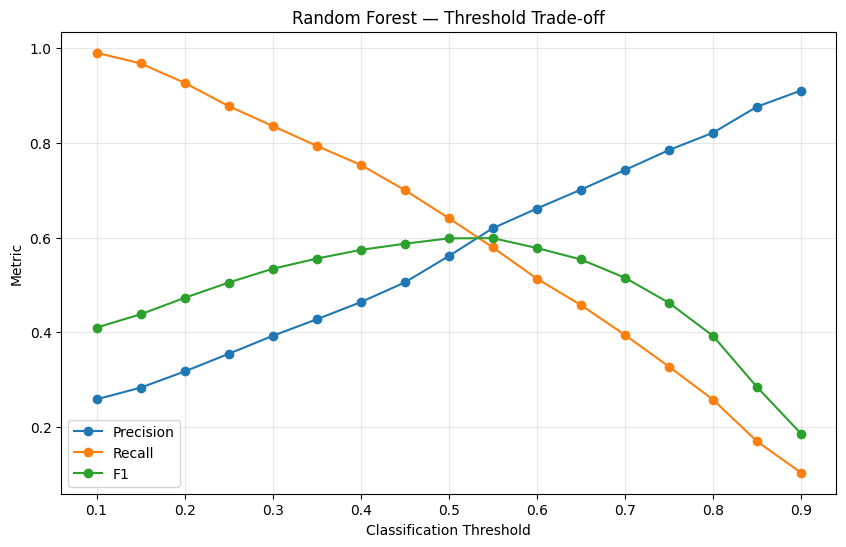

In [ ]:
# PHASE 2 — CELL 49
# Random Forest threshold trade-off

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Metric")
plt.title("Random Forest — Threshold Trade-off")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# PHASE 2 — CELL 50
# Select Random Forest classification threshold using validation set

thresholds = np.arange(0.10, 0.91, 0.01)

threshold_results = []

for threshold in thresholds:

    val_pred = (y_val_rf_proba >= threshold).astype(int)

    precision = precision_score(
        y_val,
        val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        val_pred,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_results_df = pd.DataFrame(threshold_results)

# Find threshold giving maximum validation F1
best_row = threshold_results_df.loc[
    threshold_results_df["f1"].idxmax()
]

best_threshold = best_row["threshold"]

print("Best validation threshold:", best_threshold)
print("Validation Precision:", best_row["precision"])
print("Validation Recall:", best_row["recall"])
print("Validation F1:", best_row["f1"])

Best validation threshold: 0.5399999999999998
Validation Precision: 0.6098471986417657
Validation Recall: 0.5884665792922673
Validation F1: 0.5989661497415374


In [ ]:
# PHASE 2 — CELL 51
# Final Random Forest evaluation using selected threshold

y_test_final_pred = (
    y_test_rf_proba >= best_threshold
).astype(int)

final_precision = precision_score(
    y_test,
    y_test_final_pred,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    y_test_final_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    y_test_final_pred,
    zero_division=0
)

final_accuracy = accuracy_score(
    y_test,
    y_test_final_pred
)

final_roc_auc = roc_auc_score(
    y_test,
    y_test_rf_proba
)

final_pr_auc = average_precision_score(
    y_test,
    y_test_rf_proba
)

print("====================================")
print("FINAL RANDOM FOREST TEST RESULTS")
print("====================================")

print(f"Threshold : {best_threshold:.2f}")
print(f"ROC-AUC   : {final_roc_auc:.4f}")
print(f"PR-AUC    : {final_pr_auc:.4f}")
print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_final_pred))

FINAL RANDOM FOREST TEST RESULTS
Threshold : 0.54
ROC-AUC   : 0.8230
PR-AUC    : 0.6247
Accuracy  : 0.8198
Precision : 0.5968
Recall    : 0.5696
F1 Score  : 0.5829

Confusion Matrix:
[[9781 1199]
 [1341 1775]]


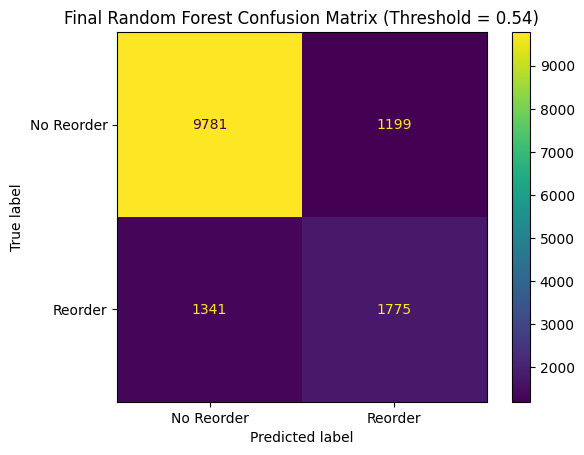

In [ ]:
# PHASE 2 — CELL 52
# Final confusion matrix

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_final_pred,
    display_labels=["No Reorder", "Reorder"]
)

plt.title(
    f"Final Random Forest Confusion Matrix "
    f"(Threshold = {best_threshold:.2f})"
)

plt.show()

In [ ]:
# PHASE 2 — CELL 53
# Random Forest feature importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print(feature_importance.round(4).to_string(index=False))

                 Feature  Importance
            recency_days        0.18
          purchase_count        0.11
           reorder_count        0.11
    min_reorder_interval        0.07
               is_repeat        0.06
  customer_lifetime_days        0.06
     sku_total_purchases        0.05
        sku_total_orders        0.05
 median_reorder_interval        0.05
            total_orders        0.05
    avg_reorder_interval        0.04
sku_customer_penetration        0.04
         avg_basket_size        0.04
    sku_unique_customers        0.04
      median_basket_size        0.02
    max_reorder_interval        0.02


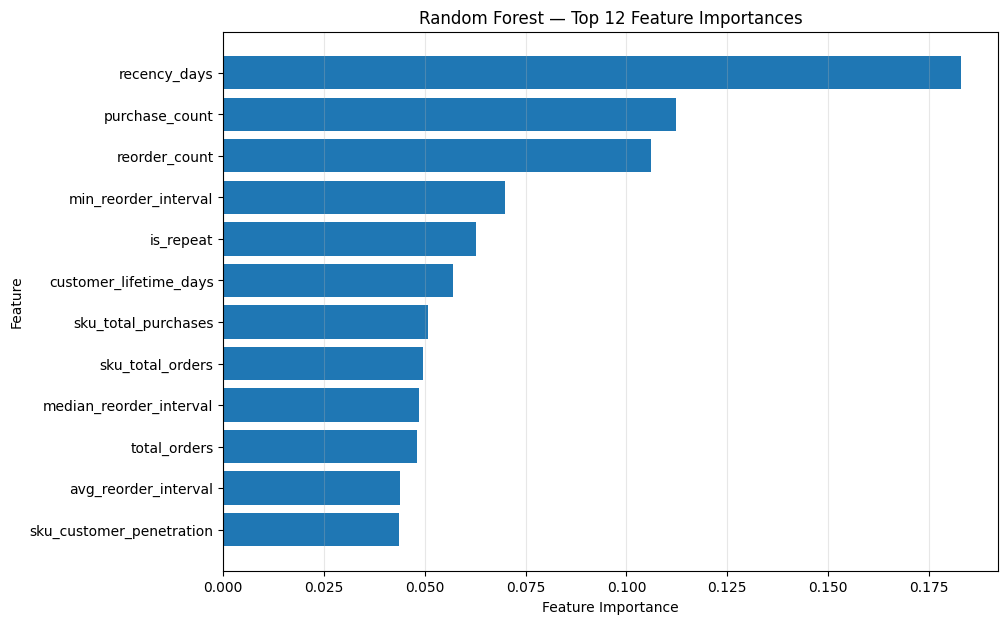

In [ ]:
# PHASE 2 — CELL 54
# Top feature importance visualization

top_features = feature_importance.head(12).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest — Top 12 Feature Importances")
plt.grid(axis="x", alpha=0.3)

plt.show()

In [ ]:
# PHASE 2 — CELL 55
# Save final model and metadata

import joblib
import os

model_path = "/content/drive/MyDrive/Phase_2_Final_Random_Forest.pkl"
metadata_path = "/content/drive/MyDrive/Phase_2_Final_Model_Metadata.pkl"

joblib.dump(
    rf_model,
    model_path
)

metadata = {
    "model": "Random Forest",
    "threshold": float(best_threshold),
    "features": list(X_train.columns),
    "validation_roc_auc": float(
        roc_auc_score(y_val, y_val_rf_proba)
    ),
    "validation_pr_auc": float(
        average_precision_score(y_val, y_val_rf_proba)
    ),
    "test_roc_auc": float(final_roc_auc),
    "test_pr_auc": float(final_pr_auc),
    "test_accuracy": float(final_accuracy),
    "test_precision": float(final_precision),
    "test_recall": float(final_recall),
    "test_f1": float(final_f1)
}

joblib.dump(
    metadata,
    metadata_path
)

print("Final model saved to:")
print(model_path)

print("\nMetadata saved to:")
print(metadata_path)

Final model saved to:
/content/drive/MyDrive/Phase_2_Final_Random_Forest.pkl

Metadata saved to:
/content/drive/MyDrive/Phase_2_Final_Model_Metadata.pkl


In [59]:
# PHASE 2 → PHASE 3 BRIDGE
# Save the final feature dataset for Phase 3

model_df_path = "/content/drive/MyDrive/Phase_2_model_df.pkl"

model_df.to_pickle(model_df_path)

print("Phase 2 feature dataset saved successfully.")
print("Path:", model_df_path)
print("Shape:", model_df.shape)
print("Columns:", list(model_df.columns))

Phase 2 feature dataset saved successfully.
Path: /content/drive/MyDrive/Phase_2_model_df.pkl
Shape: (56881, 25)
Columns: ['Member', 'SKU', 'Description', 'purchase_count', 'first_purchase', 'last_purchase', 'avg_reorder_interval', 'median_reorder_interval', 'min_reorder_interval', 'max_reorder_interval', 'reorder_count', 'is_repeat', 'recency_days', 'total_orders', 'avg_basket_size', 'median_basket_size', 'customer_first_purchase', 'customer_last_purchase', 'customer_lifetime_days', 'sku_total_purchases', 'sku_total_orders', 'sku_unique_customers', 'sku_customer_penetration', 'target_reorder', 'snapshot_date']
